<a href="https://colab.research.google.com/github/starsyntaxx/healthcare-data-analysis/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving tracy_realistic_hackathon_dataset.csv.gz to tracy_realistic_hackathon_dataset.csv.gz


In [5]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import pandas as pd

df = pd.read_csv("tracy_realistic_hackathon_dataset.csv.gz")


In [4]:
pd.set_option('display.max_columns', None)
df.head()

,user_id,timestamp,date,state,lga,latitude,longitude,movement_status,speed_mps,contact_id,bluetooth_rssi,contact_duration_sec,encounter_count_day,body_temperature_c,heart_rate_bpm,respiratory_rate,blood_oxygen_spo2,battery_percent,day_of_week,hour_of_day,weekend_flag,rainfall_mm,humidity_pct,air_quality_index
0,USR_202,2024-02-05 13:25:47,2024-02-05,Enugu,Enugu North,6.462358,7.655629,0,0.35,USR_087,-80,96,6,37.2,70,17,99.6,51,Monday,13,0,0.0,64.5,75
1,USR_015,2024-04-06 01:50:28,2024-04-06,Ogun,Ifo,7.056971,3.240695,1,2.38,USR_115,-77,290,7,36.9,79,17,97.4,69,Saturday,1,1,16.5,59.7,37
2,USR_163,2024-01-14 01:37:19,2024-01-14,Edo,Oredo,6.404186,5.438318,0,0.68,USR_175,-65,55,5,37.1,64,14,99.3,72,Sunday,1,1,0.0,65.1,37
3,USR_216,2024-06-29 18:27:58,2024-06-29,Enugu,Nsukka,6.497719,7.453183,1,2.21,USR_162,-79,22,7,36.9,75,17,98.3,43,Saturday,18,1,17.0,55.6,62
4,USR_104,2024-05-28 05:51:44,2024-05-28,Enugu,Nsukka,6.425911,7.556910,1,0.97,USR_130,-75,339,4,36.8,75,15,98.7,89,Tuesday,5,0,18.8,53.7,17


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214322 entries, 0 to 214321
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   user_id               214322 non-null  object 
 1   timestamp             214322 non-null  object 
 2   date                  214322 non-null  object 
 3   state                 214322 non-null  object 
 4   lga                   214322 non-null  object 
 5   latitude              214322 non-null  float64
 6   longitude             214322 non-null  float64
 7   movement_status       214322 non-null  int64  
 8   speed_mps             214322 non-null  float64
 9   contact_id            214322 non-null  object 
 10  bluetooth_rssi        214322 non-null  int64  
 11  contact_duration_sec  214322 non-null  int64  
 12  encounter_count_day   214322 non-null  int64  
 13  body_temperature_c    214322 non-null  float64
 14  heart_rate_bpm        214322 non-null  int64  
 15  

In [12]:
df["humidity_pct"].describe()

,humidity_pct
count,214322.000000
mean,59.572027
std,12.899307
min,16.700000
25%,50.800000
50%,57.100000
75%,65.200000
max,112.100000


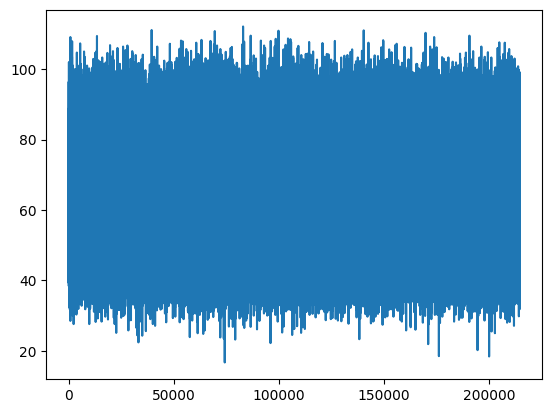

In [7]:
plt.plot(df["humidity_pct"])
plt.show()

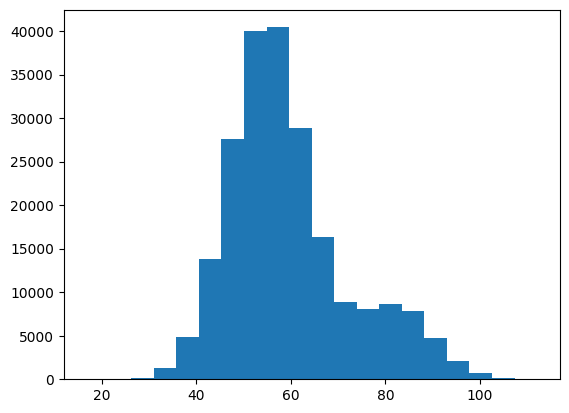

In [8]:
plt.hist(df["humidity_pct"], bins=20)
plt.show()

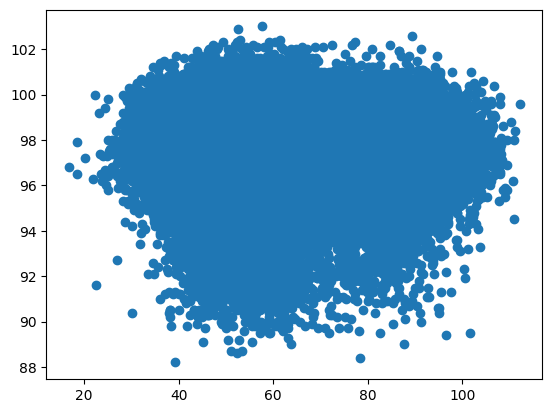

In [10]:
plt.scatter(df["humidity_pct"], df["blood_oxygen_spo2"])
plt.show()

In [13]:
X = df.select_dtypes(include=['number'])

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

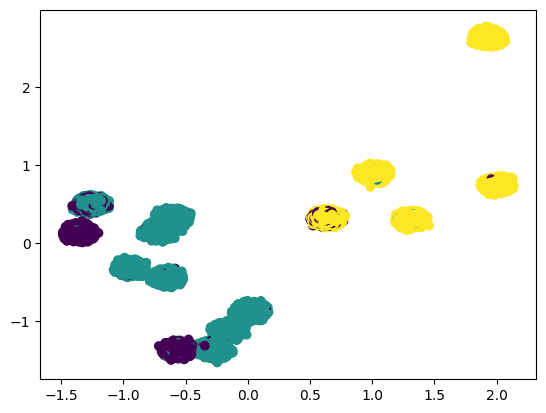

In [16]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters)
plt.show()

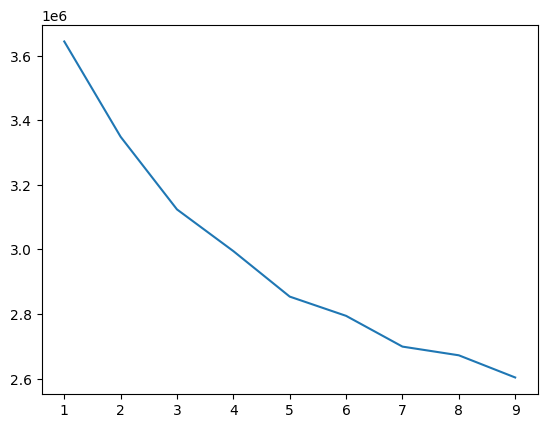

In [17]:
inertia = []

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 10), inertia)
plt.show()

In [18]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05)
df["anomaly"] = model.fit_predict(X_scaled)

In [22]:
df["anomaly"].nunique()

2

In [24]:
df[df["anomaly"] == -1]

,user_id,timestamp,date,state,lga,latitude,longitude,movement_status,speed_mps,contact_id,...,blood_oxygen_spo2,battery_percent,day_of_week,hour_of_day,weekend_flag,rainfall_mm,humidity_pct,air_quality_index,cluster,anomaly
15,USR_122,2024-04-26 01:24:18,2024-04-26,FCT,Bwari,9.013106,7.544006,0,3.19,USR_032,...,91.9,13,Friday,1,0,7.5,48.3,91,2,-1
29,USR_218,2023-11-24 03:45:39,2023-11-24,Borno,Jere,12.035990,13.145128,0,2.26,USR_208,...,94.7,29,Friday,3,0,3.9,44.5,39,2,-1
45,USR_029,2023-12-17 17:19:13,2023-12-17,Lagos,Ikeja,6.473710,3.425786,0,0.00,USR_204,...,99.4,57,Sunday,17,1,0.0,74.2,51,0,-1
62,USR_059,2023-10-03 14:53:59,2023-10-03,FCT,AMAC,8.970061,7.399056,0,3.81,USR_062,...,95.4,31,Tuesday,14,0,10.0,55.7,75,0,-1
92,USR_059,2023-10-26 03:50:55,2023-10-26,FCT,AMAC,8.991513,7.559001,1,0.76,USR_102,...,98.2,40,Thursday,3,0,4.7,50.2,104,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214078,USR_098,2023-10-17 19:08:50,2023-10-17,Borno,Jere,11.759062,13.128907,1,1.23,USR_035,...,97.1,91,Tuesday,19,0,0.0,50.3,38,2,-1
214239,USR_026,2024-04-12 19:29:37,2024-04-12,Rivers,Obio-Akpor,4.825099,7.068644,0,1.48,USR_054,...,99.0,12,Friday,19,0,15.9,89.7,55,0,-1
214240,USR_111,2024-03-02 22:52:46,2024-03-02,Lagos,Eti-Osa,6.651406,3.305017,0,0.34,USR_205,...,96.5,76,Saturday,22,1,17.3,86.5,83,0,-1
214275,USR_179,2023-12-28 13:02:46,2023-12-28,Kaduna,Kaduna North,10.317779,7.311970,0,0.00,USR_079,...,96.7,13,Thursday,13,0,0.0,72.2,77,2,-1
